# Comecando a Analise Exploratoria

In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Paleta: vermelho dos graficos de municipio + fundo branco
COR_VERMELHO = "#FF2A00"


def estilo_eixos_barra(ax, grid_axis="y"):
    """Eixos limpos (sem moldura superior/direita) e grade discreta."""
    ax.set_facecolor("#FFFFFF")
    sns.despine(ax=ax, top=True, right=True, offset=2)
    ax.grid(
        axis=grid_axis,
        linestyle=":",
        linewidth=0.85,
        alpha=0.55,
        color="#C8C8C8",
    )
    ax.set_axisbelow(True)

In [25]:
df = pd.read_csv("csvs/feminicidios_2022_2025.csv", encoding="utf-8-sig")
df.head()

,ANO_BO,ANO_ESTATISTICA,BAIRRO,DATA_OCORRENCIA_BO,DESCR_CONDUTA,DESC_PERIODO,HORA_OCORRENCIA_BO,LATITUDE,LOGRADOURO,LONGITUDE,...,NOME_DELEGACIA_CIRCUNSCRICAO,NOME_DEPARTAMENTO,NOME_DEPARTAMENTO_CIRCUNSCRICAO,NOME_MUNICIPIO,NOME_MUNICIPIO_CIRCUNSCRICAO,NOME_SECCIONAL,NOME_SECCIONAL_CIRCUNSCRICAO,NUMERO_LOGRADOURO,NUM_BO,RUBRICA
0,2022.0,2022.0,PARQUE FERNANDA,22/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,47º D.P. CAPAO REDONDO,DECAP,DECAP,S.PAULO,S.PAULO,DEL.SEC.6º SANTO AMARO,DEL.SEC.6º SANTO AMARO,NaN,AE2379,Homicídio (art. 121)
1,2022.0,2022.0,BELVEDERE,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:10:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.PENÁPOLIS,DEINTER 10 - ARAÇATUBA,DEINTER 10 - ARAÇATUBA,PENAPOLIS,PENAPOLIS,DEL.SEC.ARACATUBA,DEL.SEC.ARACATUBA,NaN,AC0317,Homicídio (art. 121)
2,2022.0,2022.0,AREA RURAL,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,19:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,01º D.P. GUARUJA,DEINTER 6 - SANTOS,DEINTER 6 - SANTOS,GUARUJA,GUARUJA,DEL.SEC.SANTOS,DEL.SEC.SANTOS,NaN,AC4630,Homicídio (art. 121)
3,2022.0,2022.0,PARQUE IMPERIAL,09/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,21:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,02º D.P. BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AB3503,Homicídio (art. 121)
4,2022.0,2022.0,JD ESPERANÇA,24/01/2022,Feminicídio-contra a mulher por razões da cond...,EM HORA INCERTA,NaN,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AF1638,Homicídio (art. 121)


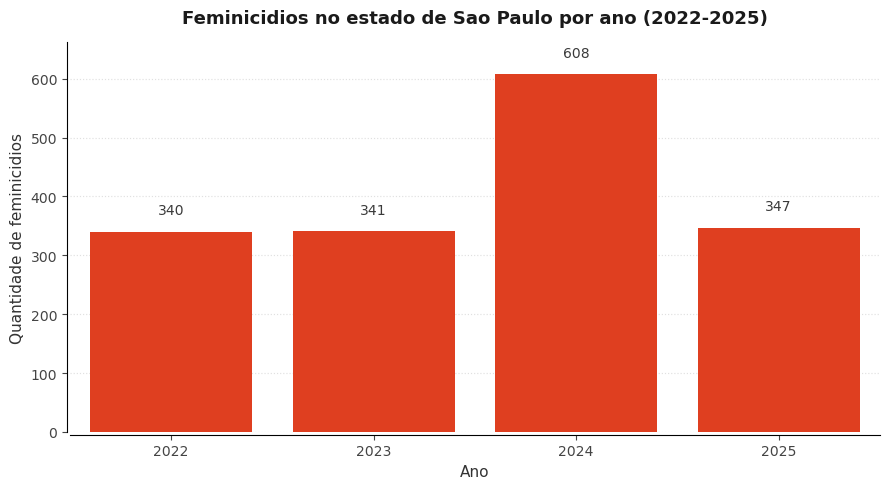

,ANO_ESTATISTICA,QTD_FEMINICIDIOS
0,2022,340
1,2023,341
2,2024,608
3,2025,347


In [26]:
feminicidios_por_ano = (
    df.assign(ANO_ESTATISTICA=df["ANO_ESTATISTICA"].astype("Int64"))
      .groupby("ANO_ESTATISTICA", dropna=True)
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("ANO_ESTATISTICA")
)

fig, ax = plt.subplots(figsize=(9, 5), facecolor="#FFFFFF")
sns.barplot(
    data=feminicidios_por_ano,
    x="ANO_ESTATISTICA",
    y="QTD_FEMINICIDIOS",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="y")
ax.set_title(
    "Feminicidios no estado de Sao Paulo por ano (2022-2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Ano", fontsize=11, color="#333333")
ax.set_ylabel("Quantidade de feminicidios", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

ymax = feminicidios_por_ano["QTD_FEMINICIDIOS"].max()
pad = max(8, ymax * 0.04)
for i, valor in enumerate(feminicidios_por_ano["QTD_FEMINICIDIOS"]):
    ax.text(
        i,
        valor + pad,
        f"{int(valor)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3a3a3a",
    )
ax.set_ylim(0, ymax + pad * 2.2)

plt.tight_layout()
plt.show()

feminicidios_por_ano

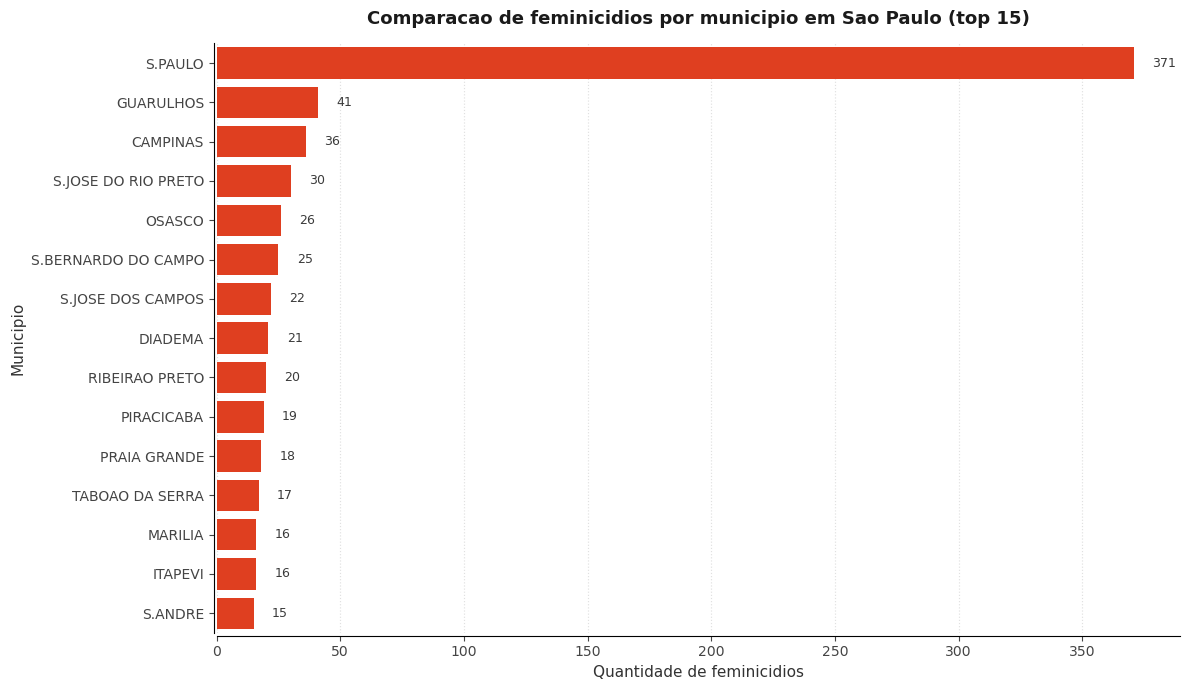

,NOME_MUNICIPIO,QTD_FEMINICIDIOS
284,S.PAULO,371
117,GUARULHOS,41
58,CAMPINAS,36
278,S.JOSE DO RIO PRETO,30
211,OSASCO,26
265,S.BERNARDO DO CAMPO,25
279,S.JOSE DOS CAMPOS,22
84,DIADEMA,21
254,RIBEIRAO PRETO,20
233,PIRACICABA,19


In [27]:
feminicidios_por_municipio = (
    df.dropna(subset=["NOME_MUNICIPIO"])
      .assign(NOME_MUNICIPIO=df["NOME_MUNICIPIO"].astype(str).str.strip())
      .groupby("NOME_MUNICIPIO")
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("QTD_FEMINICIDIOS", ascending=False)
)

top_municipios = feminicidios_por_municipio.head(15)

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")
sns.barplot(
    data=top_municipios,
    y="NOME_MUNICIPIO",
    x="QTD_FEMINICIDIOS",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Comparacao de feminicidios por municipio em Sao Paulo (top 15)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Quantidade de feminicidios", fontsize=11, color="#333333")
ax.set_ylabel("Municipio", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(1.5, top_municipios["QTD_FEMINICIDIOS"].max() * 0.02)
for index, value in enumerate(top_municipios["QTD_FEMINICIDIOS"]):
    ax.text(value + xpad, index, f"{int(value)}", va="center", fontsize=9, color="#3a3a3a")

plt.tight_layout()
plt.show()

top_municipios

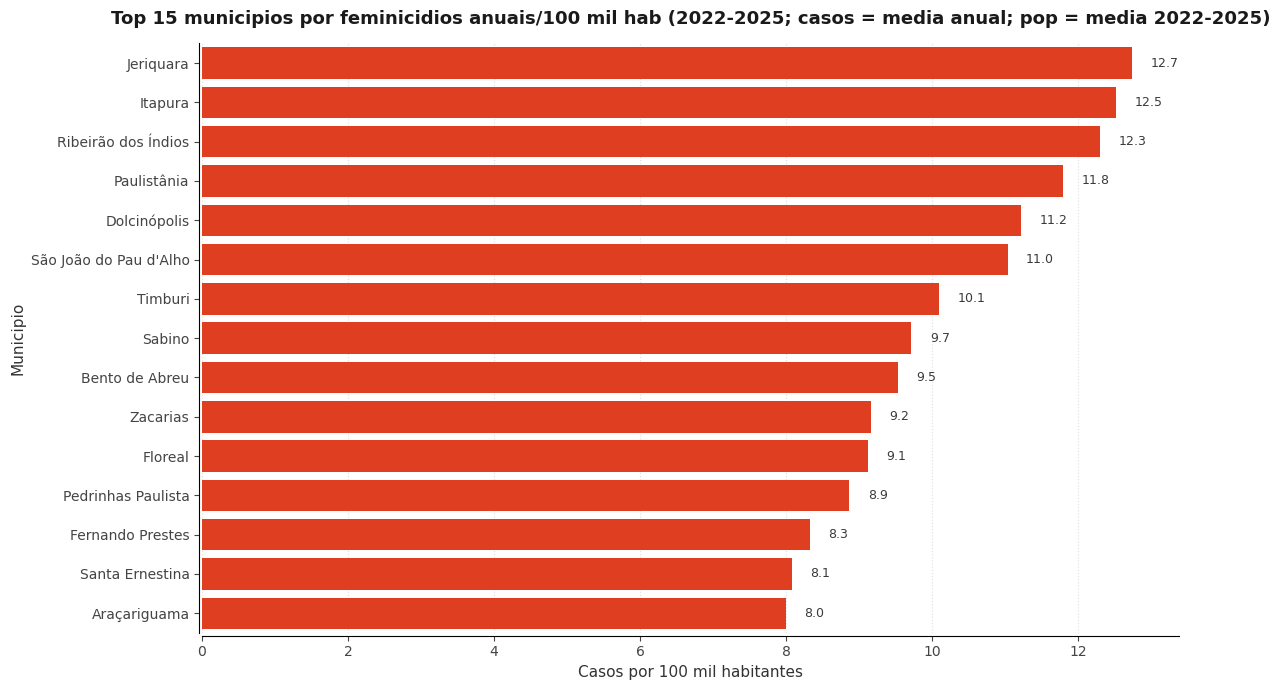

,municipio_chave,QTD_FEMINICIDIOS,id_municipio,municipio,populacao_media_2022_2025,QTD_FEMINICIDIOS_MEDIA_ANUAL,taxa_100k_hab
168,JERIQUARA,2,3525409,Jeriquara,3925.50,0.50,12.737231
151,ITAPURA,2,3523008,Itapura,3993.50,0.50,12.520346
252,RIBEIRAO DOS INDIOS,1,3543238,Ribeirão dos Índios,2033.75,0.25,12.292563
223,PAULISTANIA,1,3536570,Paulistânia,2120.50,0.25,11.789672
87,DOLCINOPOLIS,1,3514205,Dolcinópolis,2229.50,0.25,11.213277
285,SAO JOAO DO PAU DALHO,1,3549300,São João do Pau d'Alho,2266.25,0.25,11.031440
318,TIMBURI,1,3554607,Timburi,2475.50,0.25,10.098970
259,SABINO,2,3544608,Sabino,5147.75,0.50,9.712981
35,BENTO DE ABREU,1,3506201,Bento de Abreu,2623.50,0.25,9.529255
333,ZACARIAS,1,3557154,Zacarias,2729.50,0.25,9.159187


In [28]:
from municipio_sp import chave_nome_bo

pop_mean = pd.read_csv("csvs/populacao_municipio_SP_media_2022_2025.csv")

df_fem = (
    df.dropna(subset=["NOME_MUNICIPIO"])
    .assign(municipio_chave=lambda d: d["NOME_MUNICIPIO"].astype(str).str.strip().map(chave_nome_bo))
)
por_chave = (
    df_fem.groupby("municipio_chave", dropna=False)
    .size()
    .reset_index(name="QTD_FEMINICIDIOS")
)
norm_mun = por_chave.merge(pop_mean, on="municipio_chave", how="left")
anos_periodo = 4  # 2022-2025
norm_mun["QTD_FEMINICIDIOS_MEDIA_ANUAL"] = norm_mun["QTD_FEMINICIDIOS"] / anos_periodo
norm_mun["taxa_100k_hab"] = (
    norm_mun["QTD_FEMINICIDIOS_MEDIA_ANUAL"] / norm_mun["populacao_media_2022_2025"] * 100_000
)

sem_pop = norm_mun["populacao_media_2022_2025"].isna()
if sem_pop.any():
    print("Aviso: sem população para as chaves:", norm_mun.loc[sem_pop, "municipio_chave"].tolist())

norm_ok = norm_mun.dropna(subset=["populacao_media_2022_2025"])
top15_taxa = norm_ok.nlargest(15, "taxa_100k_hab")

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")
sns.barplot(
    data=top15_taxa,
    y="municipio",
    x="taxa_100k_hab",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Top 15 municipios por feminicidios anuais/100 mil hab "
    "(2022-2025; casos = media anual; pop = media 2022-2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Casos por 100 mil habitantes", fontsize=11, color="#333333")
ax.set_ylabel("Municipio", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(top15_taxa["taxa_100k_hab"]) * 0.02
for index, value in enumerate(top15_taxa["taxa_100k_hab"]):
    ax.text(value + xpad, index, f"{value:.1f}", va="center", fontsize=9, color="#3a3a3a")

plt.tight_layout()
plt.show()

top15_taxa

## Dispersão: população municipal e taxa de feminicídio

Cada ponto é um município com população conhecida na base de referência. A taxa no eixo vertical é **média anual de casos por 100 mil habitantes** (total de casos em 2022–2025 dividido por 4, sobre a população média 2022–2025).


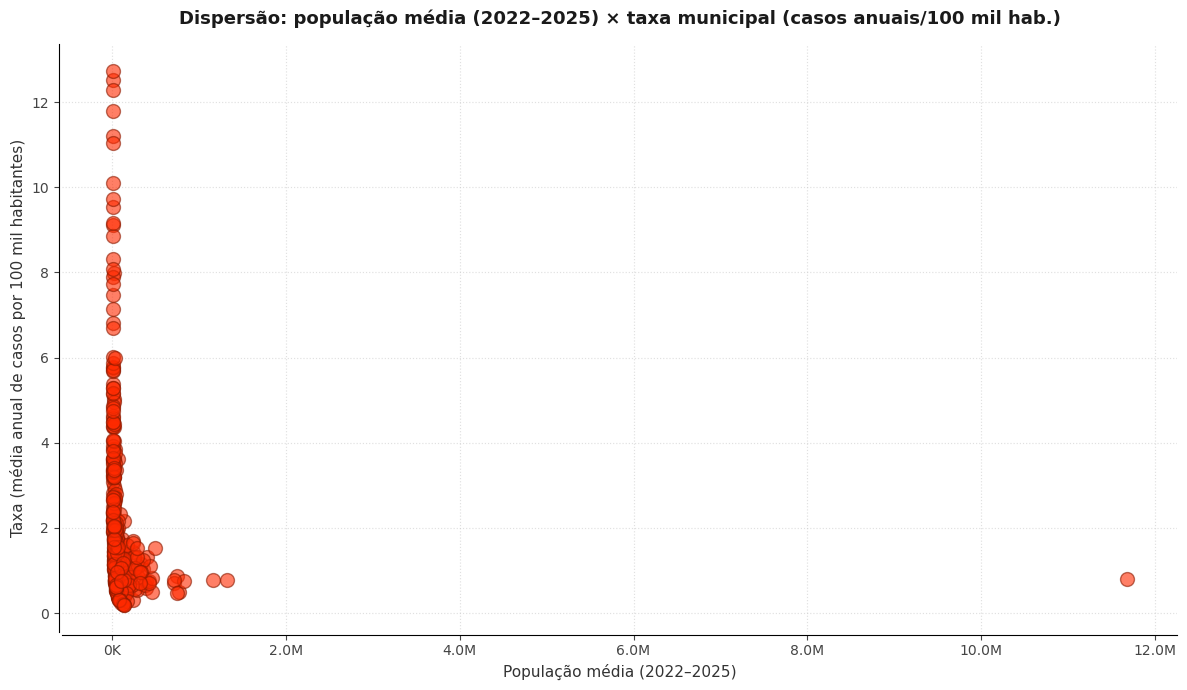

Municípios com população na base: 334
Correlação (Pearson) população × taxa: -0.109


In [30]:
fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")

scatter = ax.scatter(
    norm_ok["populacao_media_2022_2025"],
    norm_ok["taxa_100k_hab"],
    s=100,
    alpha=0.6,
    color=COR_VERMELHO,
    edgecolors="#8B1A00",
    linewidth=1,
)

ax.set_facecolor("#FFFFFF")
sns.despine(ax=ax, top=True, right=True, offset=2)
ax.grid(axis="both", linestyle=":", linewidth=0.85, alpha=0.55, color="#C8C8C8")
ax.set_axisbelow(True)

ax.set_title(
    "Dispersão: população média (2022–2025) × taxa municipal (casos anuais/100 mil hab.)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("População média (2022–2025)", fontsize=11, color="#333333")
ax.set_ylabel("Taxa (média anual de casos por 100 mil habitantes)", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

plt.tight_layout()
plt.show()

print(f"Municípios com população na base: {len(norm_ok)}")
print(
    "Correlação (Pearson) população × taxa: "
    f"{norm_ok['populacao_media_2022_2025'].corr(norm_ok['taxa_100k_hab']):.3f}"
)


## Subregiões: Capital, Demacro e Interior

Classificação adotada (mesma lógica dos totais por município já vistos no notebook):

- **Capital**: município de São Paulo (`S.PAULO` nos BOs).
- **Demacro**: nove municípios da lista fixa abaixo (região metropolitana enxuta usada na análise).
- **Interior**: demais municípios paulistas que aparecem na base de feminicídios com chave compatível com a população.

A taxa por subregião usa a **mesma padronização dos gráficos municipais**: soma dos casos em 2022–2025, convertida em **média anual** (÷ 4), dividida pela **soma das populações médias 2022–2025** dos municípios daquela subregião, × 100 mil.


In [32]:
DEMACRO_NOMES_BO = [
    "CARAPICUIBA",
    "DIADEMA",
    "FRANCO DA ROCHA",
    "GUARULHOS",
    "MOGI DAS CRUZES",
    "OSASCO",
    "SANTO ANDRE",
    "S.BERNARDO DO CAMPO",
    "TABOAO DA SERRA",
]

_DEMACRO_CHAVES = frozenset(chave_nome_bo(n) for n in DEMACRO_NOMES_BO)
_CAPITAL_CHAVE = chave_nome_bo("S.PAULO")


def rotulo_subregiao_por_chave(chave: str):
    if chave is None or (isinstance(chave, float) and pd.isna(chave)):
        return pd.NA
    if chave == _CAPITAL_CHAVE:
        return "Capital"
    if chave in _DEMACRO_CHAVES:
        return "Demacro"
    return "Interior"


norm_ok_sub = norm_ok.assign(
    subregiao=lambda d: d["municipio_chave"].map(rotulo_subregiao_por_chave)
).dropna(subset=["subregiao"])

sub_agg = (
    norm_ok_sub.groupby("subregiao", as_index=False)
    .agg(
        n_municipios=("municipio_chave", "count"),
        casos_totais=("QTD_FEMINICIDIOS", "sum"),
        pop_total=("populacao_media_2022_2025", "sum"),
    )
)
sub_agg["media_anual_casos"] = sub_agg["casos_totais"] / anos_periodo
sub_agg["taxa_100k_hab"] = (
    sub_agg["media_anual_casos"] / sub_agg["pop_total"] * 100_000
)
sub_agg = sub_agg.sort_values("taxa_100k_hab", ascending=False).reset_index(drop=True)
sub_agg


,subregiao,n_municipios,casos_totais,pop_total,media_anual_casos,taxa_100k_hab
0,Interior,324,1085,25071679.75,271.25,1.081898
1,Demacro,9,180,5331519.75,45.00,0.844037
2,Capital,1,371,11676134.25,92.75,0.794355


### Feminicídios por subregião — totais no período (sem normalização)

Soma dos registros de **2022 a 2025** para todos os municípios de cada subregião (Capital, Demacro, Interior). Mesma ideia do gráfico absoluto por município: **quantidade bruta**, sem taxa por habitante. Em seguida vem o gráfico **normalizado** (por 100 mil habitantes).


In [ ]:
plot_abs = sub_agg.sort_values("casos_totais", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
sns.barplot(
    data=plot_abs,
    y="subregiao",
    x="casos_totais",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Total de feminicidios por subregiao em Sao Paulo (2022-2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Quantidade de feminicidios (soma dos 4 anos)", fontsize=11, color="#333333")
ax.set_ylabel("Subregiao", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(1.5, plot_abs["casos_totais"].max() * 0.02)
for i, row in enumerate(plot_abs.itertuples(index=False)):
    ax.text(
        row.casos_totais + xpad,
        i,
        f"{int(row.casos_totais)}",
        va="center",
        fontsize=9,
        color="#3a3a3a",
    )

plt.tight_layout()
plt.show()


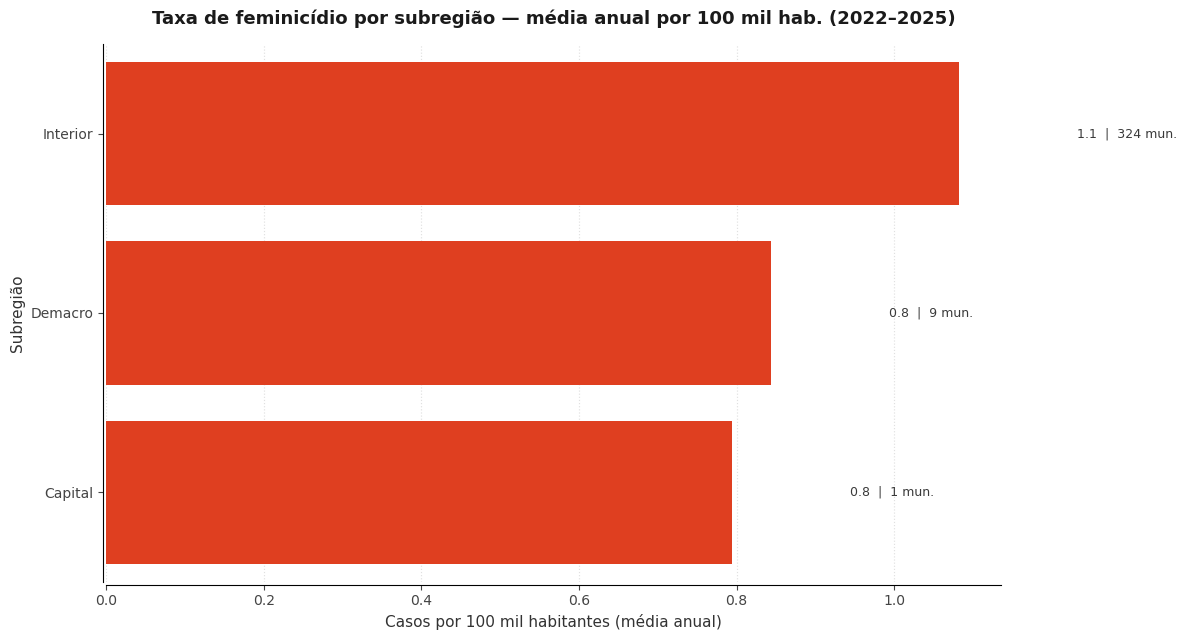

In [33]:
ordem_sub = list(sub_agg["subregiao"])
plot_sub = sub_agg.set_index("subregiao").loc[ordem_sub].reset_index()

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
sns.barplot(
    data=plot_sub,
    y="subregiao",
    x="taxa_100k_hab",
    color=COR_VERMELHO,
    order=ordem_sub,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Taxa de feminicídio por subregião — média anual por 100 mil hab. (2022–2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Casos por 100 mil habitantes (média anual)", fontsize=11, color="#333333")
ax.set_ylabel("Subregião", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(plot_sub["taxa_100k_hab"].max() * 0.02, 0.15)
for i, row in enumerate(plot_sub.itertuples(index=False)):
    ax.text(
        row.taxa_100k_hab + xpad,
        i,
        f"{row.taxa_100k_hab:.1f}  |  {int(row.n_municipios)} mun.",
        va="center",
        fontsize=9,
        color="#3a3a3a",
    )

plt.tight_layout()
plt.show()


### Distribuição das taxas municipais

Histograma das taxas **por município** (mesma métrica: média anual / 100 mil hab.). As linhas verticais marcam média e mediana — úteis para ver assimetria e municípios extremos.


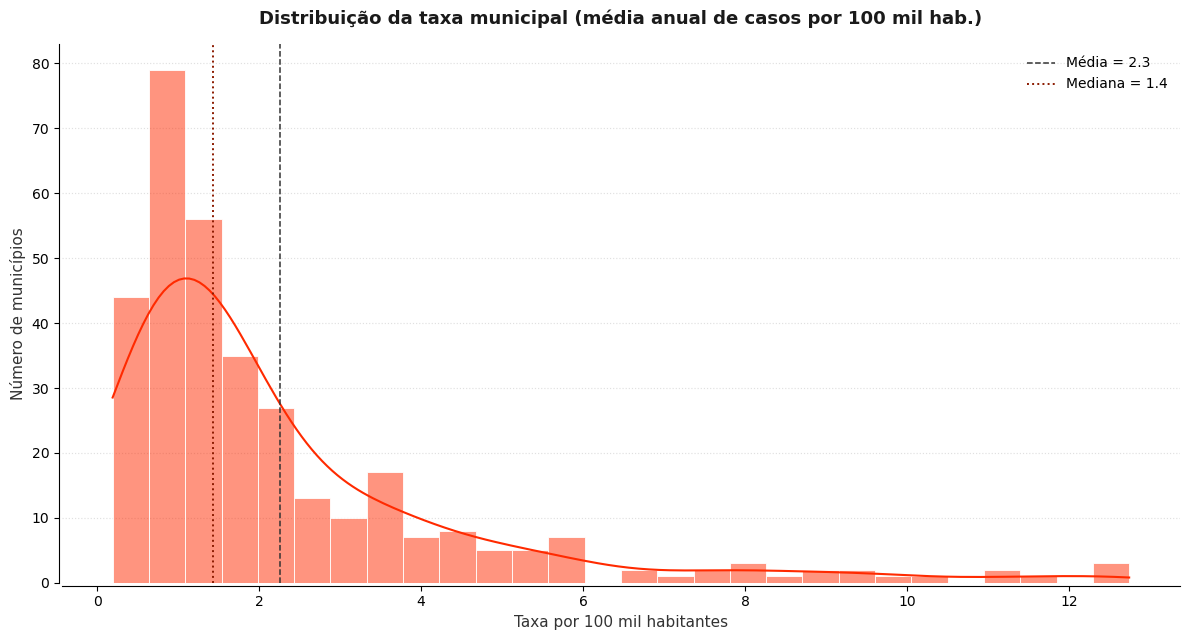

In [35]:
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
sns.histplot(
    norm_ok_sub["taxa_100k_hab"],
    bins=28,
    kde=True,
    color=COR_VERMELHO,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="y")
m = norm_ok_sub["taxa_100k_hab"].mean()
med = norm_ok_sub["taxa_100k_hab"].median()
ax.axvline(m, color="#333333", linestyle="--", linewidth=1.1, label=f"Média = {m:.1f}")
ax.axvline(med, color="#8B1A00", linestyle=":", linewidth=1.4, label=f"Mediana = {med:.1f}")
ax.set_title(
    "Distribuição da taxa municipal (média anual de casos por 100 mil hab.)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Taxa por 100 mil habitantes", fontsize=11, color="#333333")
ax.set_ylabel("Número de municípios", fontsize=11, color="#333333")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


### Dispersão das taxas entre municípios, por subregião

Boxplot + pontos (strip plot) para comparar **variabilidade interna**: a mediana e a caixa mostram a distribuição municipal dentro de Capital, Demacro e Interior.


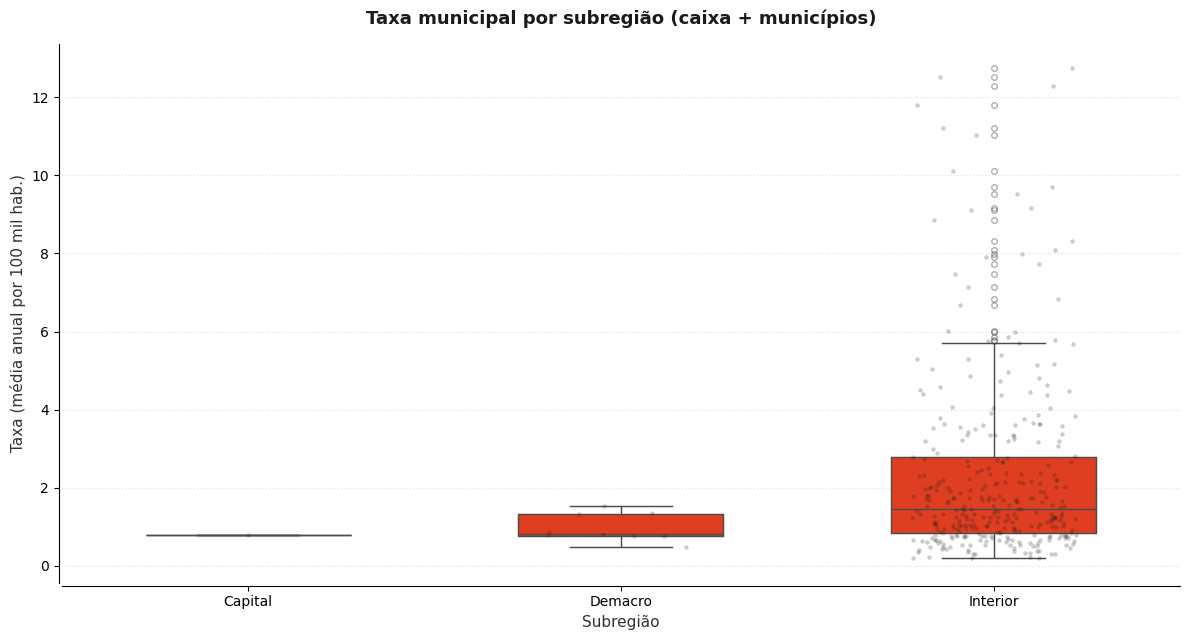

In [37]:
ordem_fixa = ["Capital", "Demacro", "Interior"]
ordem_fixa = [s for s in ordem_fixa if s in set(norm_ok_sub["subregiao"])]

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
sns.boxplot(
    data=norm_ok_sub,
    x="subregiao",
    y="taxa_100k_hab",
    order=ordem_fixa,
    color=COR_VERMELHO,
    width=0.55,
    linewidth=1.05,
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.45, "color": "#555"},
    ax=ax,
)
sns.stripplot(
    data=norm_ok_sub,
    x="subregiao",
    y="taxa_100k_hab",
    order=ordem_fixa,
    color="#1a1a1a",
    alpha=0.22,
    size=3.2,
    jitter=0.22,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="y")
ax.set_title(
    "Taxa municipal por subregião (caixa + municípios)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Subregião", fontsize=11, color="#333333")
ax.set_ylabel("Taxa (média anual por 100 mil hab.)", fontsize=11, color="#333333")
plt.tight_layout()
plt.show()


### Evolução anual dos registros por subregião

Contagem **bruta de registros na base** por ano estatístico e subregião (cada linha do CSV conta uma ocorrência). Complementa a taxa agregada: mostra ritmo temporal sem depender da população.


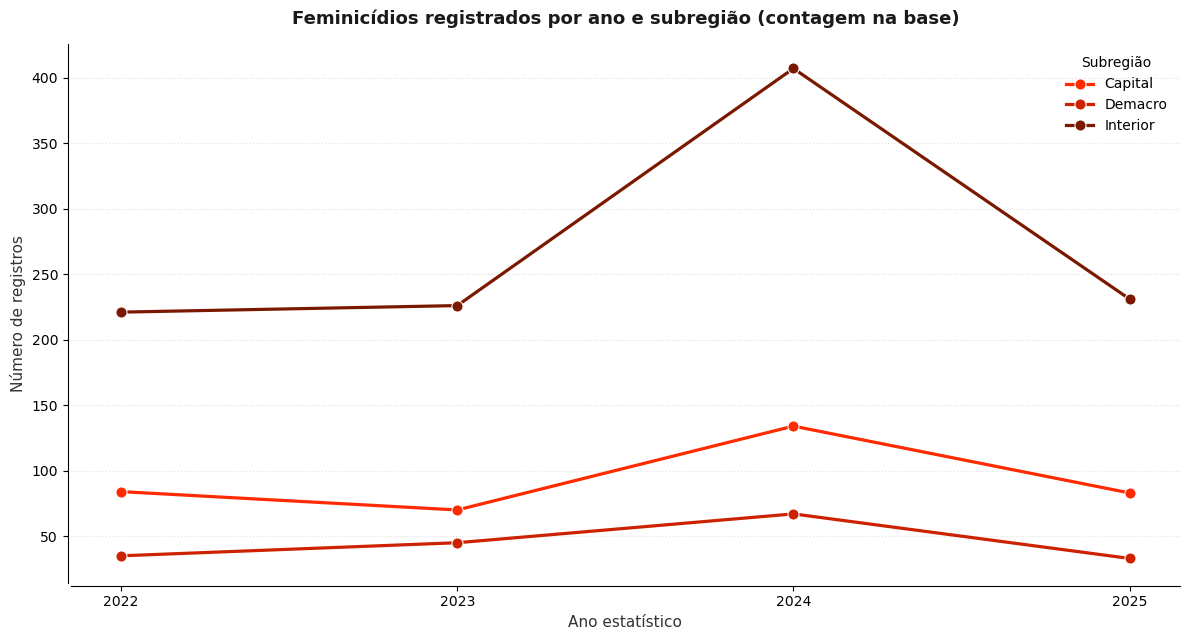

In [39]:
df_sub = (
    df.dropna(subset=["NOME_MUNICIPIO"])
    .assign(
        municipio_chave=lambda d: d["NOME_MUNICIPIO"].astype(str).str.strip().map(chave_nome_bo),
        ANO=lambda d: d["ANO_ESTATISTICA"].astype("Int64"),
    )
)
df_sub["subregiao"] = df_sub["municipio_chave"].map(rotulo_subregiao_por_chave)
df_sub = df_sub.dropna(subset=["subregiao", "ANO"])

contagem_ano = (
    df_sub.groupby(["ANO", "subregiao"], as_index=False).size().rename(columns={"size": "casos"})
)

pal_linha = {"Capital": COR_VERMELHO, "Demacro": "#CC2200", "Interior": "#7a1800"}
ordem_fixa2 = [s for s in ["Capital", "Demacro", "Interior"] if s in set(contagem_ano["subregiao"])]

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
sns.lineplot(
    data=contagem_ano,
    x="ANO",
    y="casos",
    hue="subregiao",
    hue_order=ordem_fixa2,
    palette=pal_linha,
    marker="o",
    markersize=8,
    linewidth=2.3,
    ax=ax,
)
ax.set_xticks(sorted(contagem_ano["ANO"].dropna().unique()))
ax.set_facecolor("#FFFFFF")
sns.despine(ax=ax, top=True, right=True, offset=2)
ax.grid(axis="y", linestyle=":", linewidth=0.85, alpha=0.55, color="#C8C8C8")
ax.set_axisbelow(True)
ax.set_title(
    "Feminicídios registrados por ano e subregião (contagem na base)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Ano estatístico", fontsize=11, color="#333333")
ax.set_ylabel("Número de registros", fontsize=11, color="#333333")
ax.legend(title="Subregião", frameon=False, title_fontsize=10)
plt.tight_layout()
plt.show()


### Composição percentual dos registros por ano (barras empilhadas a 100%)

Para cada ano, que fração dos casos com subregião identificada cai em Capital, Demacro ou Interior. Isso ajuda a ver **mudança de peso relativo** mesmo quando o total anual varia.


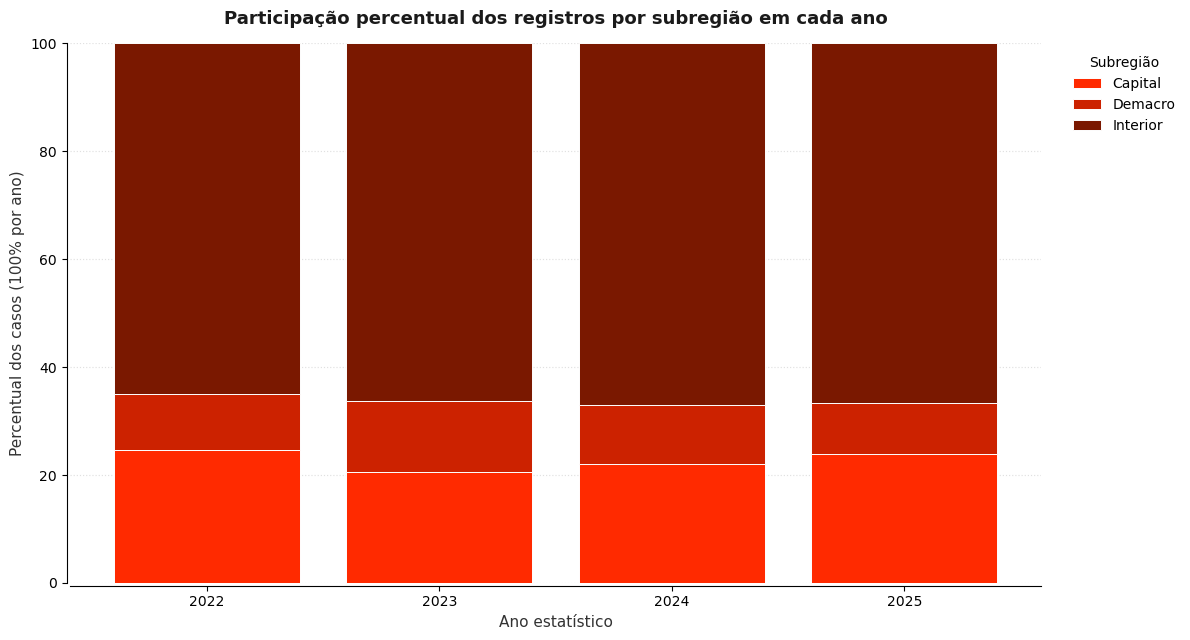

In [41]:
pivot_casos = (
    contagem_ano.pivot(index="ANO", columns="subregiao", values="casos")
    .fillna(0)
    .reindex(columns=ordem_fixa2, fill_value=0)
)
pivot_pct = pivot_casos.div(pivot_casos.sum(axis=1), axis=0) * 100

anos_u = pivot_pct.index.astype(int).tolist()
x = np.arange(len(anos_u))
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FFFFFF")
bottom = np.zeros(len(anos_u))
cores = [pal_linha[s] for s in ordem_fixa2]
for sub, cor in zip(ordem_fixa2, cores):
    vals = pivot_pct[sub].values
    ax.bar(x, vals, bottom=bottom, label=sub, color=cor, edgecolor="white", linewidth=0.7)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(anos_u)
ax.set_ylim(0, 100)
ax.set_facecolor("#FFFFFF")
sns.despine(ax=ax, top=True, right=True, offset=2)
ax.grid(axis="y", linestyle=":", linewidth=0.85, alpha=0.55, color="#C8C8C8")
ax.set_axisbelow(True)
ax.set_title(
    "Participação percentual dos registros por subregião em cada ano",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Ano", fontsize=11, color="#333333")
ax.set_ylabel("Percentual dos casos (100% por ano)", fontsize=11, color="#333333")
ax.legend(title="Subregião", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
